In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
url="https://huggingface.co/datasets/scikit-learn/iris/resolve/main/Iris.csv"
df=pd.read_csv(url)
X=df[['SepalLengthCm','SepalWidthCm']]
y=df['Species']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

KNeighborsClassifier()

Prediction


In [ ]:
y_pred=model.predict(X_test)
print("KNN Accuracy:",accuracy_score(y_test,y_pred))

KNN Accuracy: 0.7777777777777778


Visualization

Text(0.5, 1.0, 'Iris Dataset distribution')

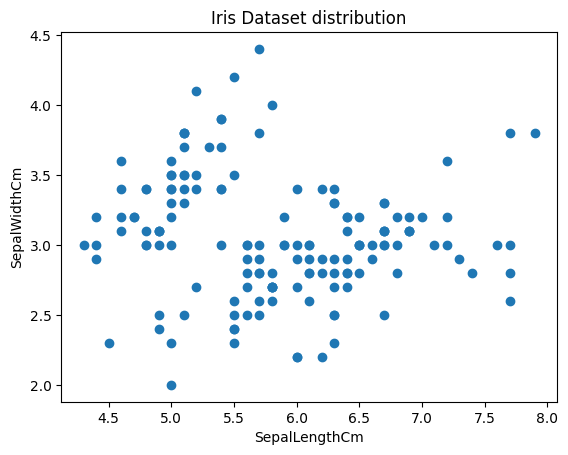

In [ ]:
plt.scatter(df['SepalLengthCm'],df['SepalWidthCm'])
plt.xlabel("SepalLengthCm")
plt.ylabel("SepalWidthCm")
plt.title("Iris Dataset distribution")


Support Vector Classifier


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
model=SVC(kernel='linear')
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("SVC Accuracy:",accuracy_score(y_test,y_pred))

SVC Accuracy: 0.8


Support Vector Regression

In [ ]:
import numpy as np
from sklearn.svm import SVR
X=np.array([1,2,3,4,5,6]).reshape(-1,1)
y=np.array([2,4,6,8,10,12])
model=SVR(kernel='rbf')
model.fit(X,y)

SVR()

prediction

In [ ]:
pred=model.predict(X)
print(pred)

[5.1254705  4.9694167  6.10000001 7.89999999 9.0305833  8.8745295 ]


Plot

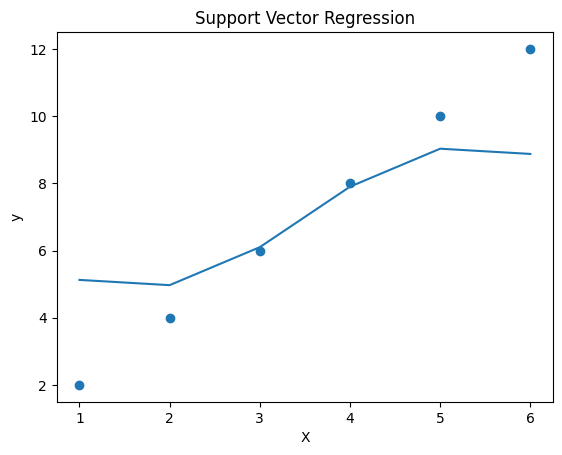

In [ ]:
plt.scatter(X,y)
plt.plot(X,pred)
plt.title("Support Vector Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

AUC-ROC Curve

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve,roc_auc_score

In [37]:
url="https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
df=pd.read_csv(url,header=None)
X=df.iloc[:,2:]
y=df.iloc[:,1]

In [38]:
y=y.replace({'M':1,'B':0})
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)
model=LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)
y_prob=model.predict_proba(X_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_prob)
auc=roc_auc_score(y_test,y_prob)
print("auc",auc)

/tmp/ipykernel_267/61806245.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y=y.replace({'M':1,'B':0})


auc 0.9976484420928865


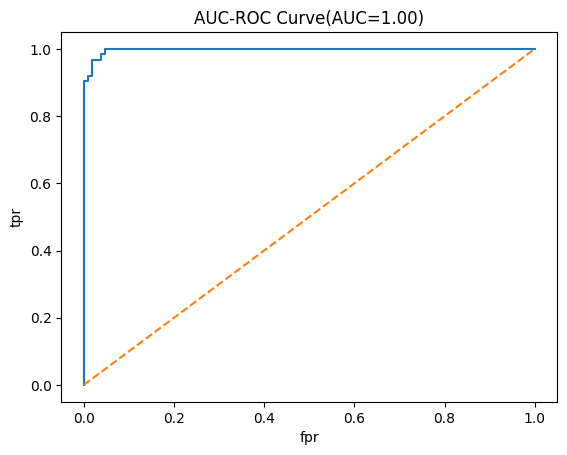

In [39]:
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("AUC-ROC Curve(AUC=%.2f)"%auc)
plt.show()